In [1]:
import sympy as sp
import numpy as np
import os
import scienceplots
import matplotlib.pyplot as plt

plt.style.use(['science','no-latex'])


In [2]:
from sympy.abc import t,S,s
from sympy import Heaviside
tau=sp.abc.tau

In [3]:
TF=1/(s*tau+1)
TF

1/(s*tau + 1)

In [4]:
#Testing signal. A unit step function
test_signal_s=sp.integrals.laplace_transform(Heaviside(t),t,s)[0]
test_signal_s

1/s

In [5]:
C_s=test_signal_s*TF
C_s

1/(s*(s*tau + 1))

In [6]:
#determine c(t)
C_t=sp.integrals.inverse_laplace_transform(C_s,s,t)
C_t

Heaviside(t) - exp(-t/tau)*Heaviside(t)

In [7]:
C_t=C_t.subs(tau,1)

In [8]:
C_t

Heaviside(t) - exp(-t)*Heaviside(t)

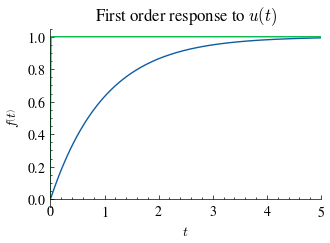

In [9]:
sp.plot(C_t,sp.Heaviside(t),title="First order response to $u(t)$",xlim=[0,5])

In [35]:
C_s=(1/s**2)*TF
C_s

1/(s**2*(s*tau + 1))

In [36]:
C_t=sp.integrals.inverse_laplace_transform(C_s,s,t)
C_t

t*Heaviside(t) - tau*Heaviside(t) + tau*exp(-t/tau)*Heaviside(t)

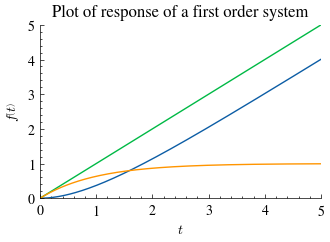

In [37]:
sp.plot(C_t.subs(tau,1),t,t-C_t.subs(tau,1),xlim=[0,5],ylim=[0,5],title="Plot of response of a first order system")
plt.show()